# Data Augmentation Samples

This notebook visualizes the augmentation pipeline: original images, balanced oversampling, and augmented outputs.

In [1]:
import sys, os
import numpy as np
import matplotlib.pyplot as plt

sys.path.insert(0, os.path.abspath('..'))

from src.data_loader import (
    IMG_CLASSES, IMG_SIZE, prepare_datasets,
    balance_classes, augment_data
)

DATASET_PATH = '../data'

## 1. Load and Split Data

In [2]:
x_train, y_train, x_valid, y_valid, x_test, y_test, y_test_onehot = prepare_datasets(DATASET_PATH)

Training:   3766 images  |  shape: (3766, 150, 150, 1)
    NORMAL: 998
    PNEUMONIA: 2768
Validation: 942 images  |  shape: (942, 150, 150, 1)
Testing:    524 images  |  shape: (524, 150, 150, 1)


## 2. Class Distribution Before Balancing

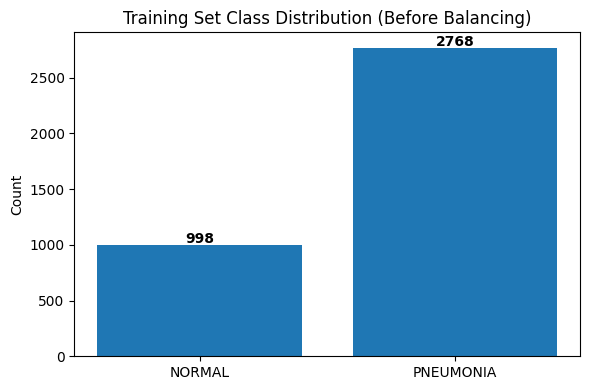

In [3]:
labels = np.argmax(y_train, axis=1)
counts_before = [np.sum(labels == i) for i in range(len(IMG_CLASSES))]

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(IMG_CLASSES, counts_before)
for bar, count in zip(bars, counts_before):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 20,
            str(count), ha='center', fontweight='bold')
ax.set_title('Training Set Class Distribution (Before Balancing)')
ax.set_ylabel('Count')
plt.tight_layout()
plt.show()

## 3. Sample Original Images Per Class

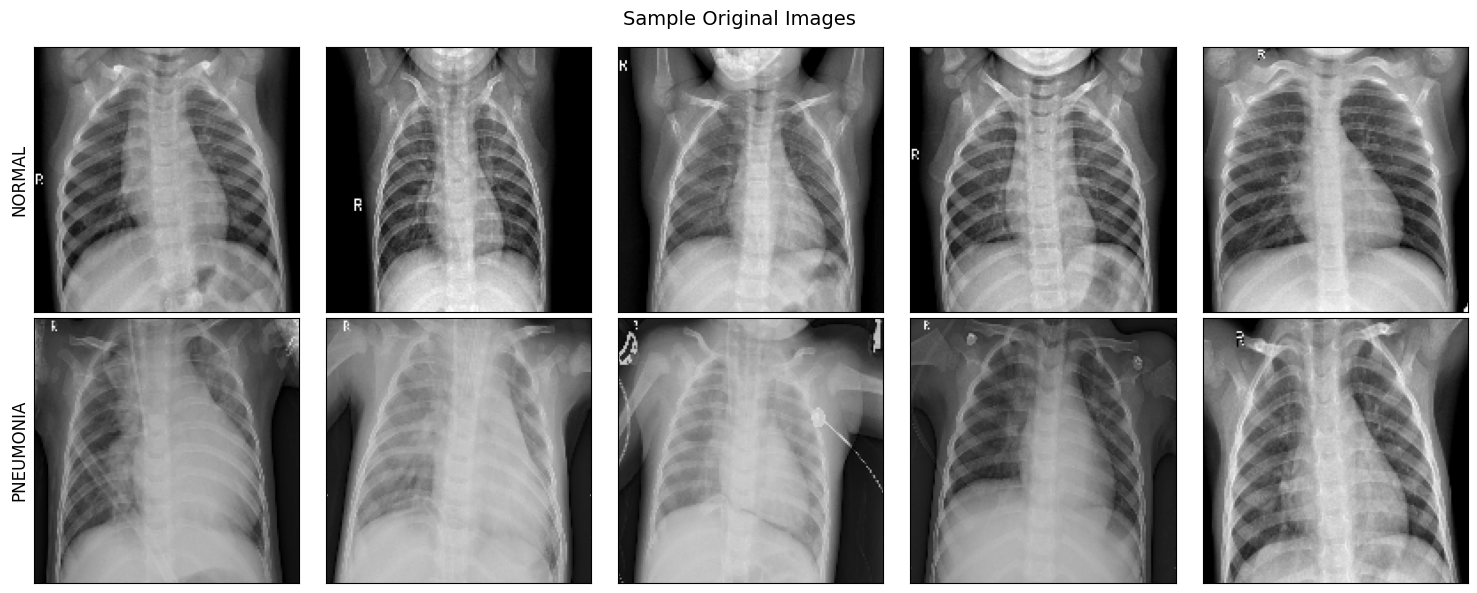

In [4]:
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
fig.suptitle('Sample Original Images', fontsize=14)

for row, cls_idx in enumerate([0, 1]):
    mask = labels == cls_idx
    samples = x_train[mask][:5]
    for col, img in enumerate(samples):
        axes[row, col].imshow(img[:, :, 0], cmap='gray')
        axes[row, col].set_xticks([])
        axes[row, col].set_yticks([])
        if col == 0:
            axes[row, col].set_ylabel(IMG_CLASSES[cls_idx], fontsize=12)

plt.tight_layout()
plt.show()

## 4. Balance Classes (Oversample Minority)

Balancing: oversampling NORMAL (998 -> 2768)
  Balanced NORMAL: 2764
  Balanced PNEUMONIA: 2768


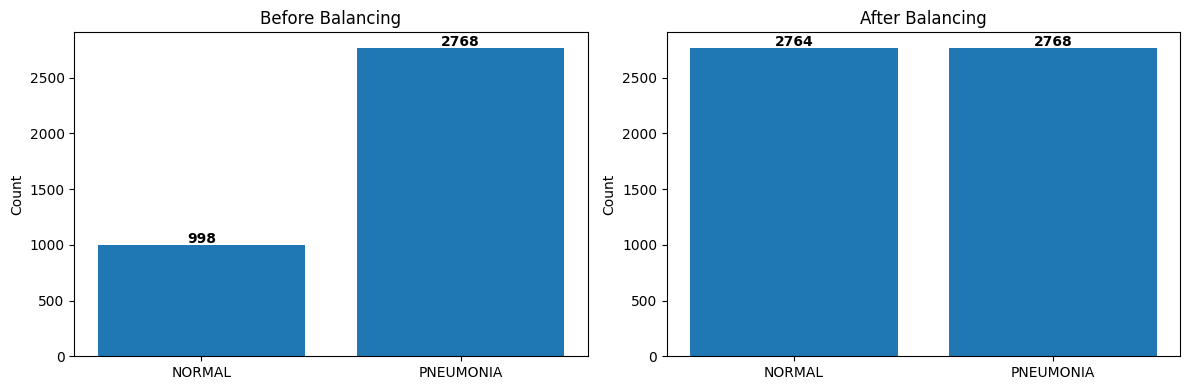

In [5]:
x_balanced, y_balanced = balance_classes(x_train, y_train)

labels_bal = np.argmax(y_balanced, axis=1)
counts_after = [np.sum(labels_bal == i) for i in range(len(IMG_CLASSES))]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(IMG_CLASSES, counts_before)
axes[0].set_title('Before Balancing')
axes[0].set_ylabel('Count')
for bar, c in zip(axes[0].patches, counts_before):
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 20,
                 str(c), ha='center', fontweight='bold')

axes[1].bar(IMG_CLASSES, counts_after)
axes[1].set_title('After Balancing')
axes[1].set_ylabel('Count')
for bar, c in zip(axes[1].patches, counts_after):
    axes[1].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 20,
                 str(c), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

## 5. Augmented Variations of a Single Image

Starting from one original image, these are the different augmented versions generated by the pipeline.

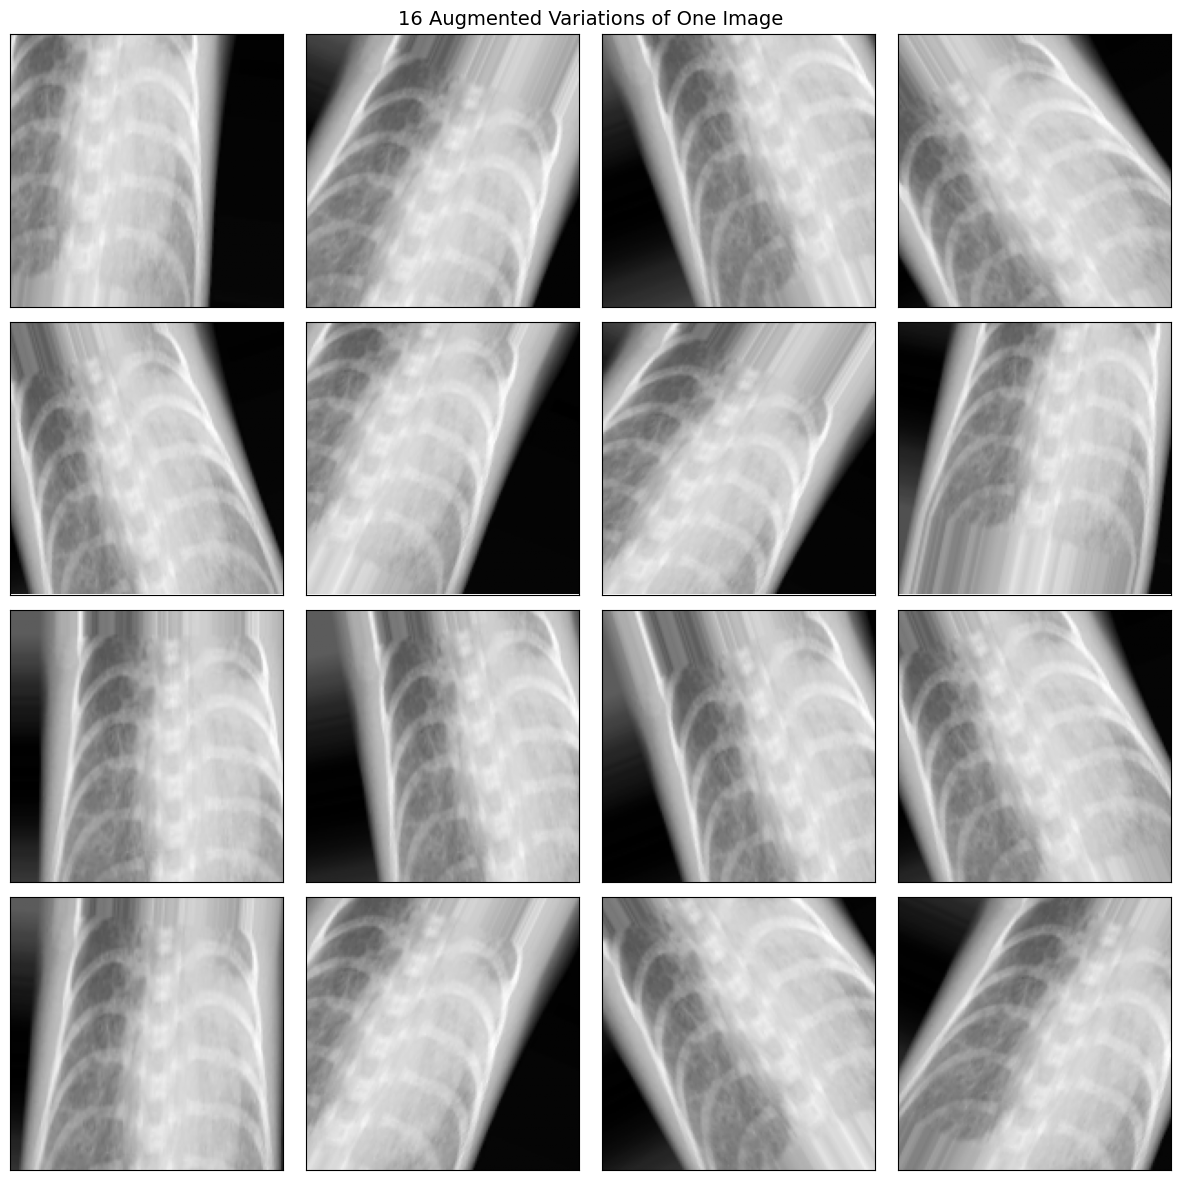

In [12]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.0,
    zoom_range=0.1,
    horizontal_flip=False
)

sample_img = x_balanced[:1]
gen = datagen.flow(sample_img, batch_size=1, seed=42)

fig, axes = plt.subplots(4, 4, figsize=(12, 12))
fig.suptitle('16 Augmented Variations of One Image', fontsize=14)

for i in range(4):
    for j in range(4):
        aug_img = next(gen)[0]
        axes[i, j].imshow(aug_img[:, :, 0], cmap='gray')
        axes[i, j].set_xticks([])
        axes[i, j].set_yticks([])

plt.tight_layout()
plt.show()

## 6. Full Augmentation (Balance + Augment)

Apply the full pipeline and show the final dataset size.

Original size: 5532  ->  Augmented size: 16596


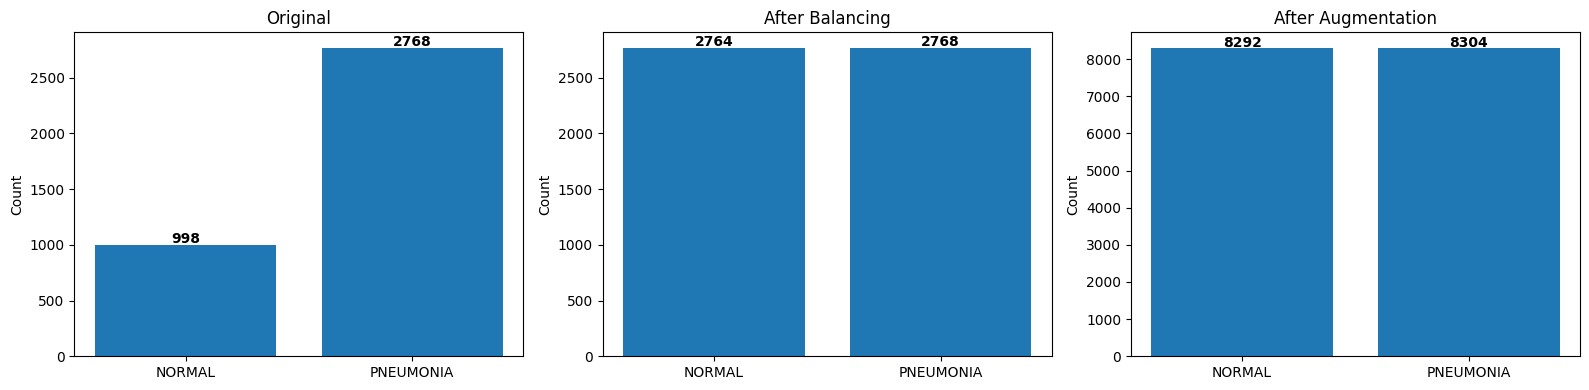


Pipeline summary:
  Original:       3766 images
  After balance:  5532 images
  After augment:  16596 images


In [7]:
x_aug, y_aug, _ = augment_data(x_balanced, y_balanced, multiplier=2)

labels_aug = np.argmax(y_aug, axis=1)
counts_aug = [np.sum(labels_aug == i) for i in range(len(IMG_CLASSES))]

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
titles = ['Original', 'After Balancing', 'After Augmentation']
all_counts = [counts_before, counts_after, counts_aug]

for ax, title, cnts in zip(axes, titles, all_counts):
    ax.bar(IMG_CLASSES, cnts)
    ax.set_title(title)
    ax.set_ylabel('Count')
    for bar, c in zip(ax.patches, cnts):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 20,
                str(c), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

print(f'\nPipeline summary:')
print(f'  Original:       {len(x_train)} images')
print(f'  After balance:  {len(x_balanced)} images')
print(f'  After augment:  {len(x_aug)} images')

## 7. Side-by-Side: Original vs Augmented

For each class, show an original image next to 3 augmented versions.

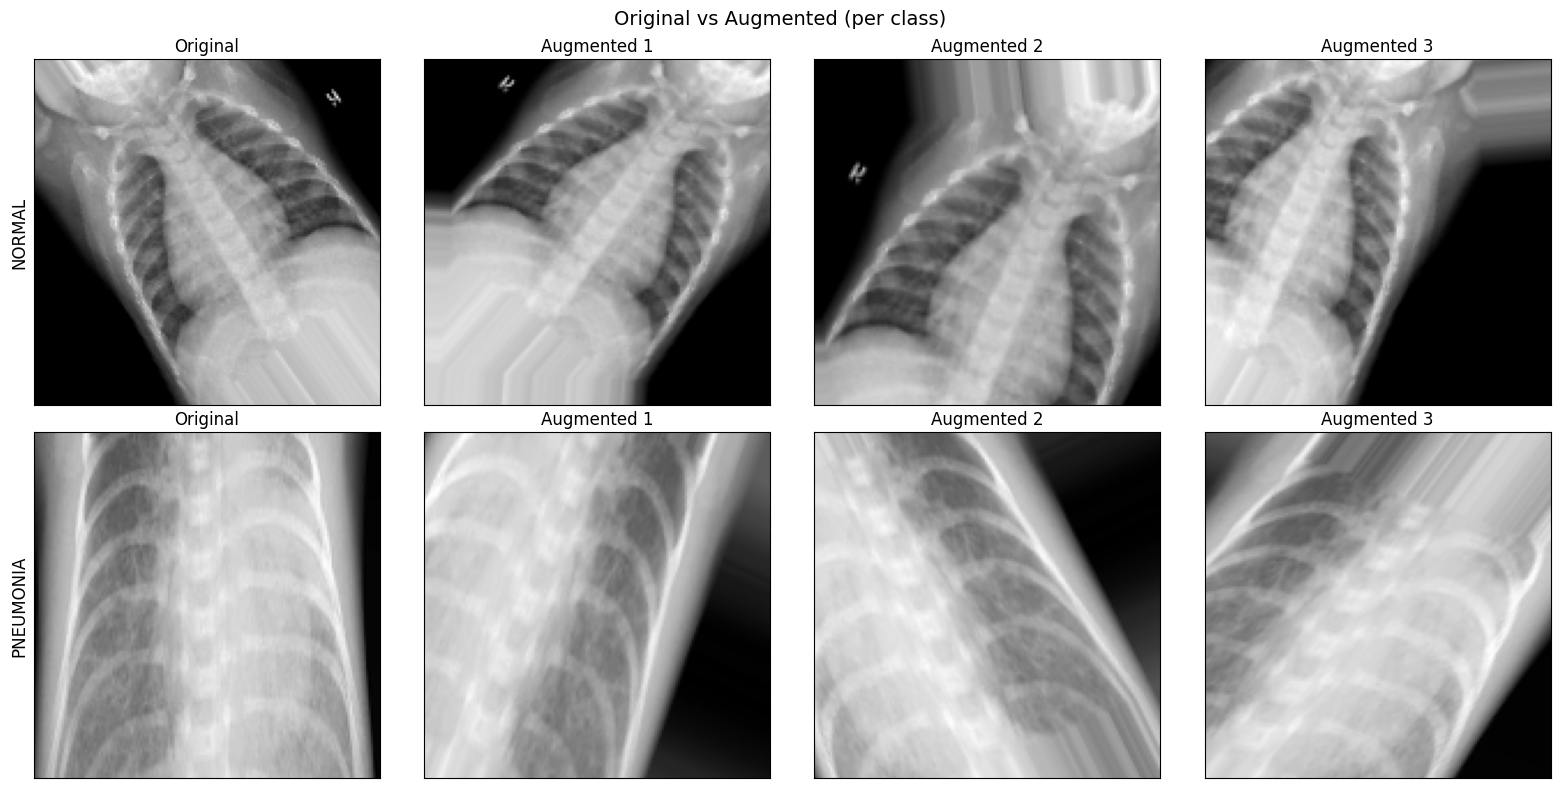

In [8]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle('Original vs Augmented (per class)', fontsize=14)

for row, cls_idx in enumerate([0, 1]):
    mask = labels_bal == cls_idx
    orig = x_balanced[mask][0:1]

    axes[row, 0].imshow(orig[0, :, :, 0], cmap='gray')
    axes[row, 0].set_title('Original')
    axes[row, 0].set_ylabel(IMG_CLASSES[cls_idx], fontsize=12)

    gen = datagen.flow(orig, batch_size=1, seed=row * 10)
    for col in range(1, 4):
        aug_img = next(gen)[0]
        axes[row, col].imshow(aug_img[:, :, 0], cmap='gray')
        axes[row, col].set_title(f'Augmented {col}')

for ax in axes.flat:
    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()
plt.show()